## Qubit characterization notebook

This is an example notebook that run through the standard qubit characterization experiments.

In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from system_info import BOARD_IP, YAML_PATH, DATA_DIR
from acadia_qmsmt.helpers.yaml_editor import update_yaml, load_yaml


### generate random pulse

YAML file config.yaml updated with {'test_oct_stimulus.pulses.oct_pulse.data': '/home/chao/github/acadia_qmsmt/acadia_qmsmt/measurements/oct_pulses/test_oct_pulse.npy'}


{'qb_stimulus': {'channel': 'DAC0', 'channel_config': {'vop': 30000, 'mix_reconstruction': True, 'nco_frequency': 8097711962.0}, 'pulses': {'R_x_180': {'data': 'hann', 'scale': 0.68918, 'ramp': 1.2e-07, 'flat': 1e-07, 'use_stretch': True}, 'R_x_180_selective': {'data': 'hann', 'scale': 0.05228, 'ramp': 4e-07, 'flat': 5e-06, 'use_stretch': True}, 'R_x_90': {'data': 'hann', 'scale': 0.32665, 'ramp': 1.2e-07, 'flat': 1e-07, 'use_stretch': True}, 'R_x_180_selective_ef': {'data': 'hann', 'scale': 0.04036, 'ramp': 4e-07, 'flat': 5e-06, 'detune': -156597379.0, 'use_stretch': False}, 'R_x_180_ef': {'data': 'hann', 'scale': 0.38864, 'ramp': 4e-07, 'detune': -156597379.0, 'use_stretch': False}}}, 'ro_stimulus': {'channel': 'DAC2', 'channel_config': {'vop': 25000, 'mix_reconstruction': True, 'nco_frequency': 9000800000.0}, 'pulses': {'readout': {'data': 'hann', 'scale': '(0.35, 0deg)', 'ramp': 1.2e-07, 'flat': 1e-06, 'use_stretch': True}}}, 'ro_capture': {'channel': 'ADC0', 'channel_config': {'nc

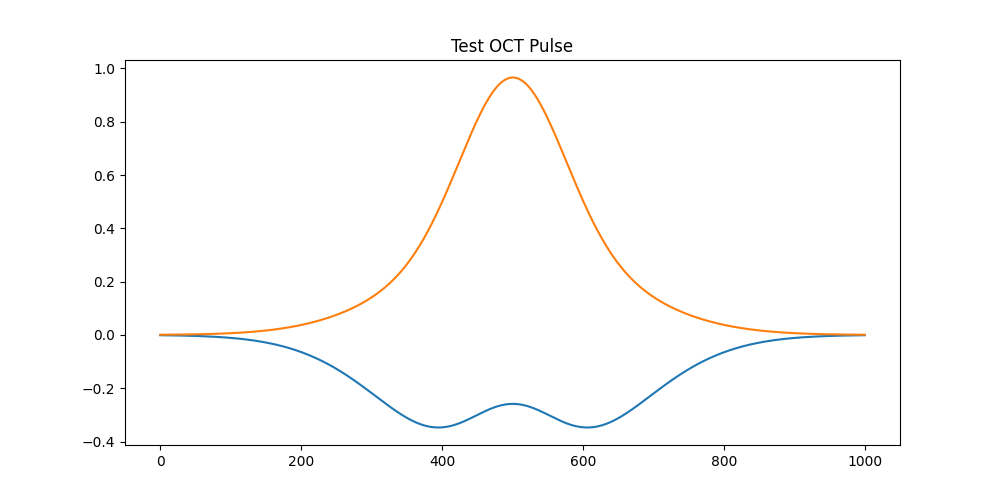

In [2]:
sampling_points = np.arange(0, 1000, 1) # 1.25 ns per sampling point
test_oct_pulse = np.exp(-(sampling_points-500)**2/100**2) + 1j*np.exp(-(sampling_points-500)**2/200**2)
test_oct_pulse/= np.max(np.abs(test_oct_pulse))*np.exp(-1j*np.pi/3)  # normalize pulse 

# test_oct_pulse = np.ones(len(sampling_points), dtype=np.complex128) # constant pulse

# # test plot#
plt.figure(figsize=(10, 5))
plt.plot(sampling_points, np.real(test_oct_pulse), label='Real Part')
plt.plot(sampling_points, np.imag(test_oct_pulse), label='Imaginary Part')
plt.title('Test OCT Pulse')

# save data and update YAML
save_oct_path = f"./oct_pulses/test_oct_pulse.npy"
Path(save_oct_path).parent.mkdir(parents=True, exist_ok=True)
np.save(save_oct_path, test_oct_pulse)
update_yaml(YAML_PATH, {"test_oct_stimulus.pulses.oct_pulse.data":str(Path(save_oct_path).absolute())}, verbose=True)


# test loopback

In [ ]:
from acadia_qmsmt.runtimes.loopback_amp_sweep import LoopbackAmpSweepRuntime
iterations = 20000

oct_pulse_name = "oct_pulse"
amp_list = 0.6*np.exp(-1j*np.pi/2) # if None, will use the amplitude in yaml file 
nco_frequency = 8.8e9  # Hz. If None, will use the frequency in yaml file 
capture_delay = 200e-9

rt = LoopbackAmpSweepRuntime(stimulus="test_oct_stimulus", capture="ro_capture",
                              stimulus_pulse_name=oct_pulse_name,
                              capture_delay=capture_delay,
                              amp_list=amp_list, nco_frequency=nco_frequency,
                           iterations=iterations, yaml_path=YAML_PATH)
rt.deploy(BOARD_IP, local_directory=DATA_DIR + "testLoopback/%y%m%d_%H%M%S")
rt.display()